# MS/MS Fragment Assignment: 분자식 기반 조각이온 할당

## 왜 Fragment Assignment가 필요한가?

Ch.03에서 분자식 → m/z를 예측했고, Ch.05 (다음 장)에서 미지 피크의 분자식을 역추적합니다.  
하지만 **같은 m/z에 여러 분자식 후보**가 존재할 수 있습니다.

예: m/z 226.009에 대응 가능한 분자식이 5개라면, 어떤 게 맞는지 어떻게 확인할까요?

**답: MS/MS (충돌 유도 분해)**

분자를 충돌시켜 조각내면, 그 **조각이온(fragment)의 패턴이 부모 분자식의 지문**이 됩니다.  
fragment가 부모 분자식과 논리적으로 맞아떨어지면 : 그 분자식이 맞다는 강력한 증거입니다.




- "이 fragment는 부모에서 어떤 원소를 잃어서 생겼는가" 직접 추론

## 이 챕터의 로직 흐름



---

In [1]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl


### Library Import 및 환경 설정

- NumPy, Pandas, Matplotlib, pyOpenMS 등 fragment 분석에 필요한 라이브러리를 로드합니다.
- itertools.product를 이용하여 가능한 sub-formula 조합을 체계적으로 열거할 준비를 합니다.
- 그래프 설정을 통일하여 MS/MS 스펙트럼 시각화의 일관성을 확보합니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyopenms as oms
import math, os, warnings
from itertools import product as iterproduct
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print('준비 완료.')

---
## 1. Sub-formula Enumeration

부모 분자식 C7H5N3O6 (TNT)에서 **부모보다 작거나 같은 모든 원소 조합**을 열거합니다.  
이것이 fragment 후보가 됩니다.

예: C7H5N3O6의 sub-formula
- C7H4N3O5 (NO 손실)
- C7H5N2O4 (NO2 손실)
- C6H4N2O4 (CHO + N 손실)
- ...

**제약 조건:**
- 각 원소 개수 <= 부모의 해당 원소 개수
- monoisotopic mass가 실측 fragment m/z 근방

In [ ]:
ATOMIC_MASS = {
    'C': 12.000000, 'H': 1.007825, 'N': 14.003074,
    'O': 15.994915, 'S': 31.972071,
}
PROTON = 1.00728

def parse_formula(formula):
    import re
    elements = {}
    for match in re.finditer(r'([A-Z][a-z]?)(\d*)', formula):
        sym = match.group(1)
        cnt = int(match.group(2)) if match.group(2) else 1
        if sym:
            elements[sym] = elements.get(sym, 0) + cnt
    return elements

def calc_mass(elements):
    return sum(ATOMIC_MASS.get(s, 0) * n for s, n in elements.items())

def calc_dbe(elements):
    C = elements.get('C', 0)
    H = elements.get('H', 0)
    N = elements.get('N', 0)
    return (2*C + 2 - H + N) / 2.0

def enumerate_sub_formulas(parent_formula, target_mz, tolerance_ppm=5.0,
                            adduct_shift=-PROTON):
    """부모 분자식의 sub-formula 중 target_mz에 매칭되는 것 열거"""
    parent = parse_formula(parent_formula)
    neutral_target = target_mz - adduct_shift
    tol_da = neutral_target * tolerance_ppm * 1e-6
    
    results = []
    syms = sorted(parent.keys())
    ranges = [range(0, parent[s] + 1) for s in syms]
    
    for combo in iterproduct(*ranges):
        elem = {s: n for s, n in zip(syms, combo) if n > 0}
        if not elem:
            continue
        mass = calc_mass(elem)
        if abs(mass - neutral_target) <= tol_da:
            dbe = calc_dbe(elem)
            formula_str = ''.join(f'{s}{n}' if n > 1 else s for s, n in sorted(elem.items()) if n > 0)
            error_ppm = (mass - neutral_target) / neutral_target * 1e6
            n_electrons = sum(n for n in elem.values())  # simplified
            is_even = (int(2 * abs(dbe) + 0.5) % 2 == 0)
            results.append({
                'formula': formula_str,
                'mass': mass,
                'error_ppm': round(error_ppm, 2),
                'dbe': dbe,
                'even_electron': is_even,
                'elements': elem,
            })
    
    return sorted(results, key=lambda x: abs(x['error_ppm']))

# Test: TNT (C7H5N3O6) parent, fragment at m/z 197 (NO2 loss)
test = enumerate_sub_formulas('C7H5N3O6', 196.999, tolerance_ppm=10)
print(f'C7H5N3O6 sub-formulas matching m/z 197.0 (+/- 10 ppm):')
for r in test[:5]:
    print(f'  {r["formula"]:15s} mass={r["mass"]:.4f} err={r["error_ppm"]:+.1f}ppm DBE={r["dbe"]:.1f} even={r["even_electron"]}')

---
## 2. MRM-HR MS/MS Data Load

실측 MS/MS 스펙트럼을 로드하고, 각 fragment 피크에 분자식을 할당합니다.

In [ ]:
import os, pyopenms as oms

exp_mrm = oms.MSExperiment()
oms.MzMLFile().load('echo-tof-colab/data/mzml/20260330_MRMHR_Q1Q3_Final.mzML', exp_mrm)

def get_best_msms(exp, precursor_mz, tol_ppm=50):
    tol = precursor_mz * tol_ppm * 1e-6
    best_mz, best_int, best_total = None, None, 0
    for spec in exp:
        if spec.getMSLevel() != 2: continue
        precs = spec.getPrecursors()
        if not precs: continue
        if abs(precs[0].getMZ() - precursor_mz) <= tol:
            mz, intensity = spec.get_peaks()
            if len(mz) > 0 and np.sum(intensity) > best_total:
                best_mz, best_int = mz, intensity
                best_total = np.sum(intensity)
    return best_mz, best_int

# TNT MS/MS: precursor 226.009 [M-H]-
tnt_frag_mz, tnt_frag_int = get_best_msms(exp_mrm, 226.009)
print(f'MRM-HR: {exp_mrm.getNrSpectra()} spectra')
print(f'TNT MS/MS: {len(tnt_frag_mz)} fragments')
print(f'Top 5:')
top5 = np.argsort(tnt_frag_int)[-5:][::-1]
for idx in top5:
    rel = tnt_frag_int[idx] / tnt_frag_int.max() * 100
    print(f'  m/z={tnt_frag_mz[idx]:.4f}  rel={rel:.1f}%')


---
## 3. Fragment Assignment

각 MS/MS 피크에 대해:
1. 부모 분자식(C7H5N3O6)의 sub-formula 열거
2. 실측 m/z와 매칭 (< 5 ppm)
3. DBE >= -0.5 필터
4. 부모에 포함되는 조합만 유지
5. 최소 오차 후보 선택

이것이 **"이 fragment는 어떤 원소 조합에서 왔는가"** 를 알려줍니다.

In [ ]:
def assign_fragments(parent_formula, frag_mz_arr, frag_int_arr,
                      tolerance_ppm=10.0, adduct_shift=-PROTON,
                      min_rel_int=2.0):
    """MS/MS fragment assignment
    
    For each fragment peak:
    1. Enumerate sub-formulas matching that m/z
    2. Filter by DBE, electron state, parent containment
    3. Select best (minimum error)
    """
    parent = parse_formula(parent_formula)
    parent_dbe = calc_dbe(parent)
    max_int = frag_int_arr.max()
    
    assignments = []
    
    for i in range(len(frag_mz_arr)):
        rel_int = frag_int_arr[i] / max_int * 100
        if rel_int < min_rel_int:
            continue
        
        candidates = enumerate_sub_formulas(
            parent_formula, frag_mz_arr[i],
            tolerance_ppm=tolerance_ppm, adduct_shift=adduct_shift
        )
        
        # Filter
        valid = []
        for c in candidates:
            if c['dbe'] < -0.5:
                continue
            if c['dbe'] > parent_dbe + 1:
                continue
            # Parent containment
            contained = all(c['elements'].get(s, 0) <= parent.get(s, 0)
                          for s in c['elements'])
            if not contained:
                continue
            valid.append(c)
        
        if valid:
            best = min(valid, key=lambda x: abs(x['error_ppm']))
            # Neutral loss = parent - fragment
            loss = {}
            for s in parent:
                diff = parent[s] - best['elements'].get(s, 0)
                if diff > 0:
                    loss[s] = diff
            loss_str = ''.join(f'{s}{n}' if n > 1 else s for s, n in sorted(loss.items()) if n > 0)
            loss_mass = calc_mass(loss)
            
            assignments.append({
                'frag_mz': frag_mz_arr[i],
                'frag_int': frag_int_arr[i],
                'rel_int': rel_int,
                'assigned_formula': best['formula'],
                'assigned_mass': best['mass'],
                'error_ppm': best['error_ppm'],
                'dbe': best['dbe'],
                'even_electron': best['even_electron'],
                'neutral_loss': loss_str,
                'loss_mass': loss_mass,
                'n_candidates': len(valid),
            })
        else:
            assignments.append({
                'frag_mz': frag_mz_arr[i],
                'frag_int': frag_int_arr[i],
                'rel_int': rel_int,
                'assigned_formula': None,
                'assigned_mass': None,
                'error_ppm': None,
                'dbe': None,
                'even_electron': None,
                'neutral_loss': None,
                'loss_mass': None,
                'n_candidates': 0,
            })
    
    return assignments

# TNT fragment assignment
tnt_assignments = assign_fragments('C7H5N3O6', tnt_frag_mz, tnt_frag_int,
                                    tolerance_ppm=10, min_rel_int=2.0)

print(f'TNT (C7H5N3O6) [M-H]- MS/MS Fragment Assignment')
print(f'{"m/z":>10s} {"Rel%":>6s} {"Formula":>15s} {"err(ppm)":>9s} {"DBE":>5s} {"Loss":>12s} {"Loss mass":>10s}')
print('-' * 75)
for a in tnt_assignments:
    if a['assigned_formula']:
        print(f'{a["frag_mz"]:10.4f} {a["rel_int"]:6.1f} {a["assigned_formula"]:>15s} '
              f'{a["error_ppm"]:+9.1f} {a["dbe"]:5.1f} {a["neutral_loss"]:>12s} {a["loss_mass"]:10.4f}')
    else:
        print(f'{a["frag_mz"]:10.4f} {a["rel_int"]:6.1f} {"-- unassigned --":>15s}')

### Annotated MS/MS Spectrum 시각화

- Fragment 할당 결과를 실측 MS/MS 스펙트럼 위에 annotation으로 표시합니다.
- 할당된 fragment에는 분자식과 neutral loss 정보를 레이블로 추가합니다.
- 미할당(unassigned) fragment는 회색으로 표시하여, 추가 해석이 필요한 피크를 시각적으로 구분합니다.

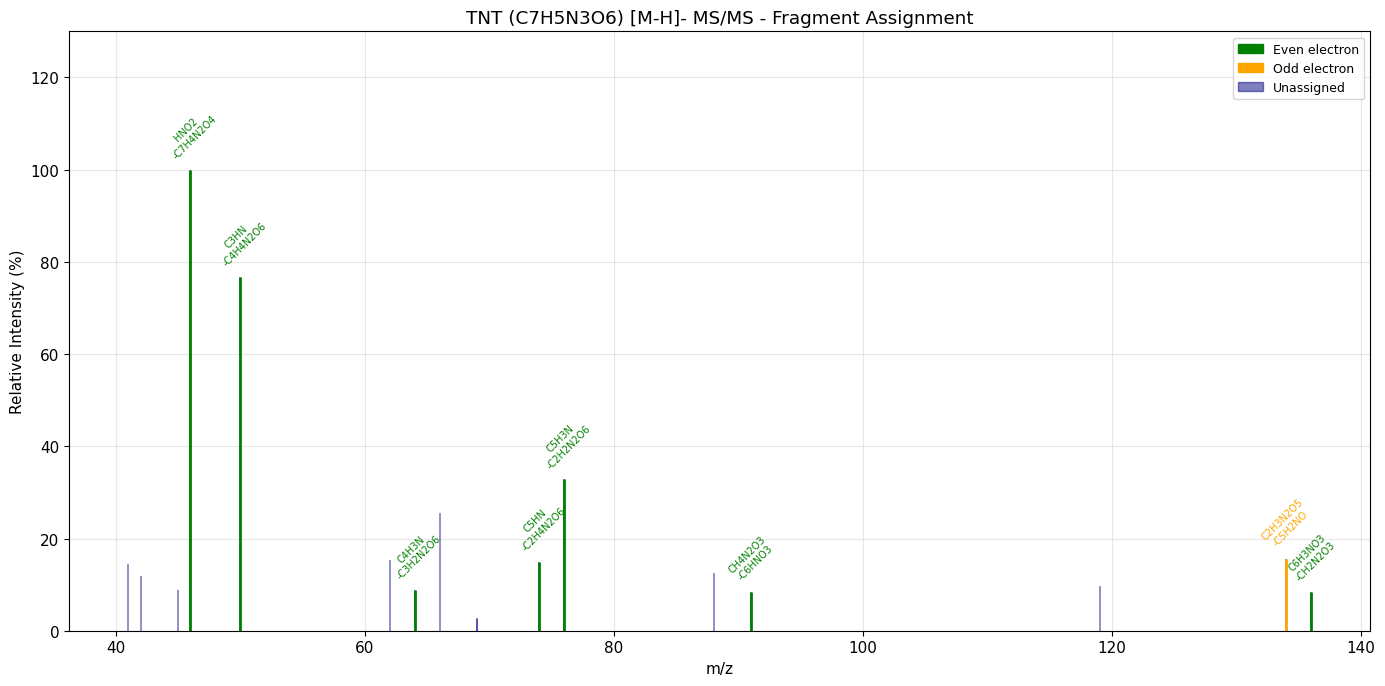

In [1]:
# Annotated MS/MS spectrum
fig, ax = plt.subplots(figsize=(14, 7))

# Stick plot
rel_int = tnt_frag_int / tnt_frag_int.max() * 100
ax.vlines(tnt_frag_mz, 0, rel_int, colors='navy', linewidth=1.2, alpha=0.5)

# Annotate assigned fragments
for a in tnt_assignments:
    if a['assigned_formula']:
        color = 'green' if a['even_electron'] else 'orange'
        ax.vlines(a['frag_mz'], 0, a['rel_int'], colors=color, linewidth=2)
        label = f"{a['assigned_formula']}\n-{a['neutral_loss']}" if a['neutral_loss'] else a['assigned_formula']
        ax.annotate(label, (a['frag_mz'], a['rel_int']),
                   textcoords='offset points', xytext=(0, 8),
                   fontsize=7, ha='center', color=color, rotation=45)

ax.set_xlabel('m/z')
ax.set_ylabel('Relative Intensity (%)')
ax.set_title('TNT (C7H5N3O6) [M-H]- MS/MS - Fragment Assignment')
ax.set_ylim(0, 130)
ax.grid(alpha=0.3)

from matplotlib.patches import Patch
legend = [Patch(color='green', label='Even electron'),
          Patch(color='orange', label='Odd electron'),
          Patch(color='navy', alpha=0.5, label='Unassigned')]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Water Loss Chain Detection

연속적인 물(H2O, 18.011 Da) 손실은 fragment 스펙트럼에서 흔합니다.  
이 패턴을 자동 검출하면 DBE 제약 조건을 동적으로 조정할 수 있습니다.

```
[M-H]-  →  [M-H-H2O]-  →  [M-H-2H2O]-  →  [M-H-3H2O]-
226.009    208.000        189.989         171.978
           -18.011        -18.011         -18.011
```

In [ ]:
WATER_MASS = 18.010565

def detect_water_loss_chains(frag_mz_arr, frag_int_arr, tolerance_ppm=10):
    """Consecutive water loss chain detection"""
    n = len(frag_mz_arr)
    chain = [-1] * n  # chain[i] = j means i lost H2O to become j
    
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if frag_mz_arr[j] >= frag_mz_arr[i]: continue
            tol = frag_mz_arr[i] * tolerance_ppm * 1e-6
            diff = abs(frag_mz_arr[i] - frag_mz_arr[j] - WATER_MASS)
            if diff <= tol:
                chain[i] = j
    
    # Find longest chain
    chains = []
    for start in range(n):
        path = [start]
        current = start
        visited = {start}
        while chain[current] >= 0 and chain[current] not in visited:
            current = chain[current]
            visited.add(current)
            path.append(current)
        if len(path) > 1:
            chains.append(path)
    
    return chains

chains = detect_water_loss_chains(tnt_frag_mz, tnt_frag_int)
print(f'Water loss chains found: {len(chains)}')
for i, chain in enumerate(chains):
    print(f'  Chain {i+1}: ', end='')
    mzs = [f'{tnt_frag_mz[idx]:.3f}' for idx in chain]
    print(' -> '.join(mzs) + f'  ({len(chain)-1}x H2O loss)')

---
## 5. Weighted Fragment Error

전체 MS/MS 스펙트럼에 대한 **종합 점수**를 계산합니다.

- **할당된 fragment**: 실제 mass error 사용
- **미할당 fragment**: tolerance를 penalty로 부여
- **강도 가중 평균**: 강한 피크의 오차가 더 중요

$$\text{Score} = \frac{\sum w_i \cdot \epsilon_i}{\sum w_i}$$

- $w_i$: fragment intensity (weight)
- $\epsilon_i$: assigned → |error_ppm|, unassigned → tolerance (penalty)

In [ ]:
def weighted_fragment_score(assignments, frag_int_arr, tolerance_ppm=10.0):
    """Intensity-weighted fragment error score"""
    total_weight = 0.0
    total_error = 0.0
    assigned_count = 0
    
    for a in assignments:
        weight = a['frag_int']
        if a['assigned_formula']:
            error = abs(a['error_ppm'])
            assigned_count += 1
        else:
            error = tolerance_ppm  # penalty
        
        total_weight += weight
        total_error += weight * error
    
    avg_error = total_error / total_weight if total_weight > 0 else 999
    assign_rate = assigned_count / len(assignments) * 100 if assignments else 0
    
    return avg_error, assigned_count, len(assignments), assign_rate

score, n_assigned, n_total, rate = weighted_fragment_score(
    tnt_assignments, tnt_frag_int
)
print(f'TNT Fragment Assignment Score:')
print(f'  Weighted error: {score:.2f} ppm')
print(f'  Assigned: {n_assigned}/{n_total} ({rate:.0f}%)')

### 전체 화합물 일괄 Fragment 분석

- TNT, 2,4-DNT, HMX, Tetryl 등 모든 대상 화합물에 대해 fragment assignment를 자동 실행합니다.
- 각 화합물의 precursor m/z에서 MS/MS 스펙트럼을 추출하고, 부모 분자식 기준으로 fragment를 할당합니다.
- Neutral loss 패턴과 weighted score를 화합물별로 비교하여 구조적 공통점과 차이점을 파악합니다.

In [ ]:
# Run for all compounds
COMPOUNDS = {
    'TNT':      {'formula': 'C7H5N3O6',  'precursor_mz': 226.009},
    '2,4-DNT':  {'formula': 'C7H6N2O4',  'precursor_mz': 181.012},
    'HMX':      {'formula': 'C4H8N8O8',  'precursor_mz': 355.059},
    'Tetryl':   {'formula': 'C7H5N5O8',  'precursor_mz': 241.020},
    'RDX':      {'formula': 'C3H6N6O6',  'precursor_mz': 281.048},
    '4-Am-DNT': {'formula': 'C7H7N3O4',  'precursor_mz': 196.036},
}

all_results = []

print(f'{"Compound":12s} {"Formula":12s} {"Assigned":>10s} {"Rate":>6s} {"Score":>8s}')
print('-' * 55)

for name, info in COMPOUNDS.items():
    fmz, fint = get_best_msms(exp_mrm, info['precursor_mz'])
    if fmz is None:
        print(f'{name:12s} {info["formula"]:12s} {"no MS/MS":>10s}')
        continue
    
    assignments = assign_fragments(
        info['formula'], fmz, fint,
        tolerance_ppm=10, min_rel_int=3.0
    )
    score, n_a, n_t, rate = weighted_fragment_score(assignments, fint)
    
    all_results.append({
        'name': name, 'formula': info['formula'],
        'n_assigned': n_a, 'n_total': n_t,
        'rate': rate, 'score': score,
        'assignments': assignments,
        'frag_mz': fmz, 'frag_int': fint,
    })
    
    print(f'{name:12s} {info["formula"]:12s} {n_a:>3d}/{n_t:<3d}     {rate:5.0f}% {score:8.2f}')

### 전체 화합물 Annotated MS/MS 시각화

- 모든 화합물의 annotated MS/MS 스펙트럼을 한 figure에 서브플롯으로 배치합니다.
- 각 서브플롯에서 할당된 fragment의 분자식과 neutral loss를 명시하여, 화합물 간 fragmentation 패턴을 직접 비교합니다.
- Bond cleavage 규칙(예: NO2 손실, H2O 손실)이 화합물 구조와 일관되는지 시각적으로 검증합니다.

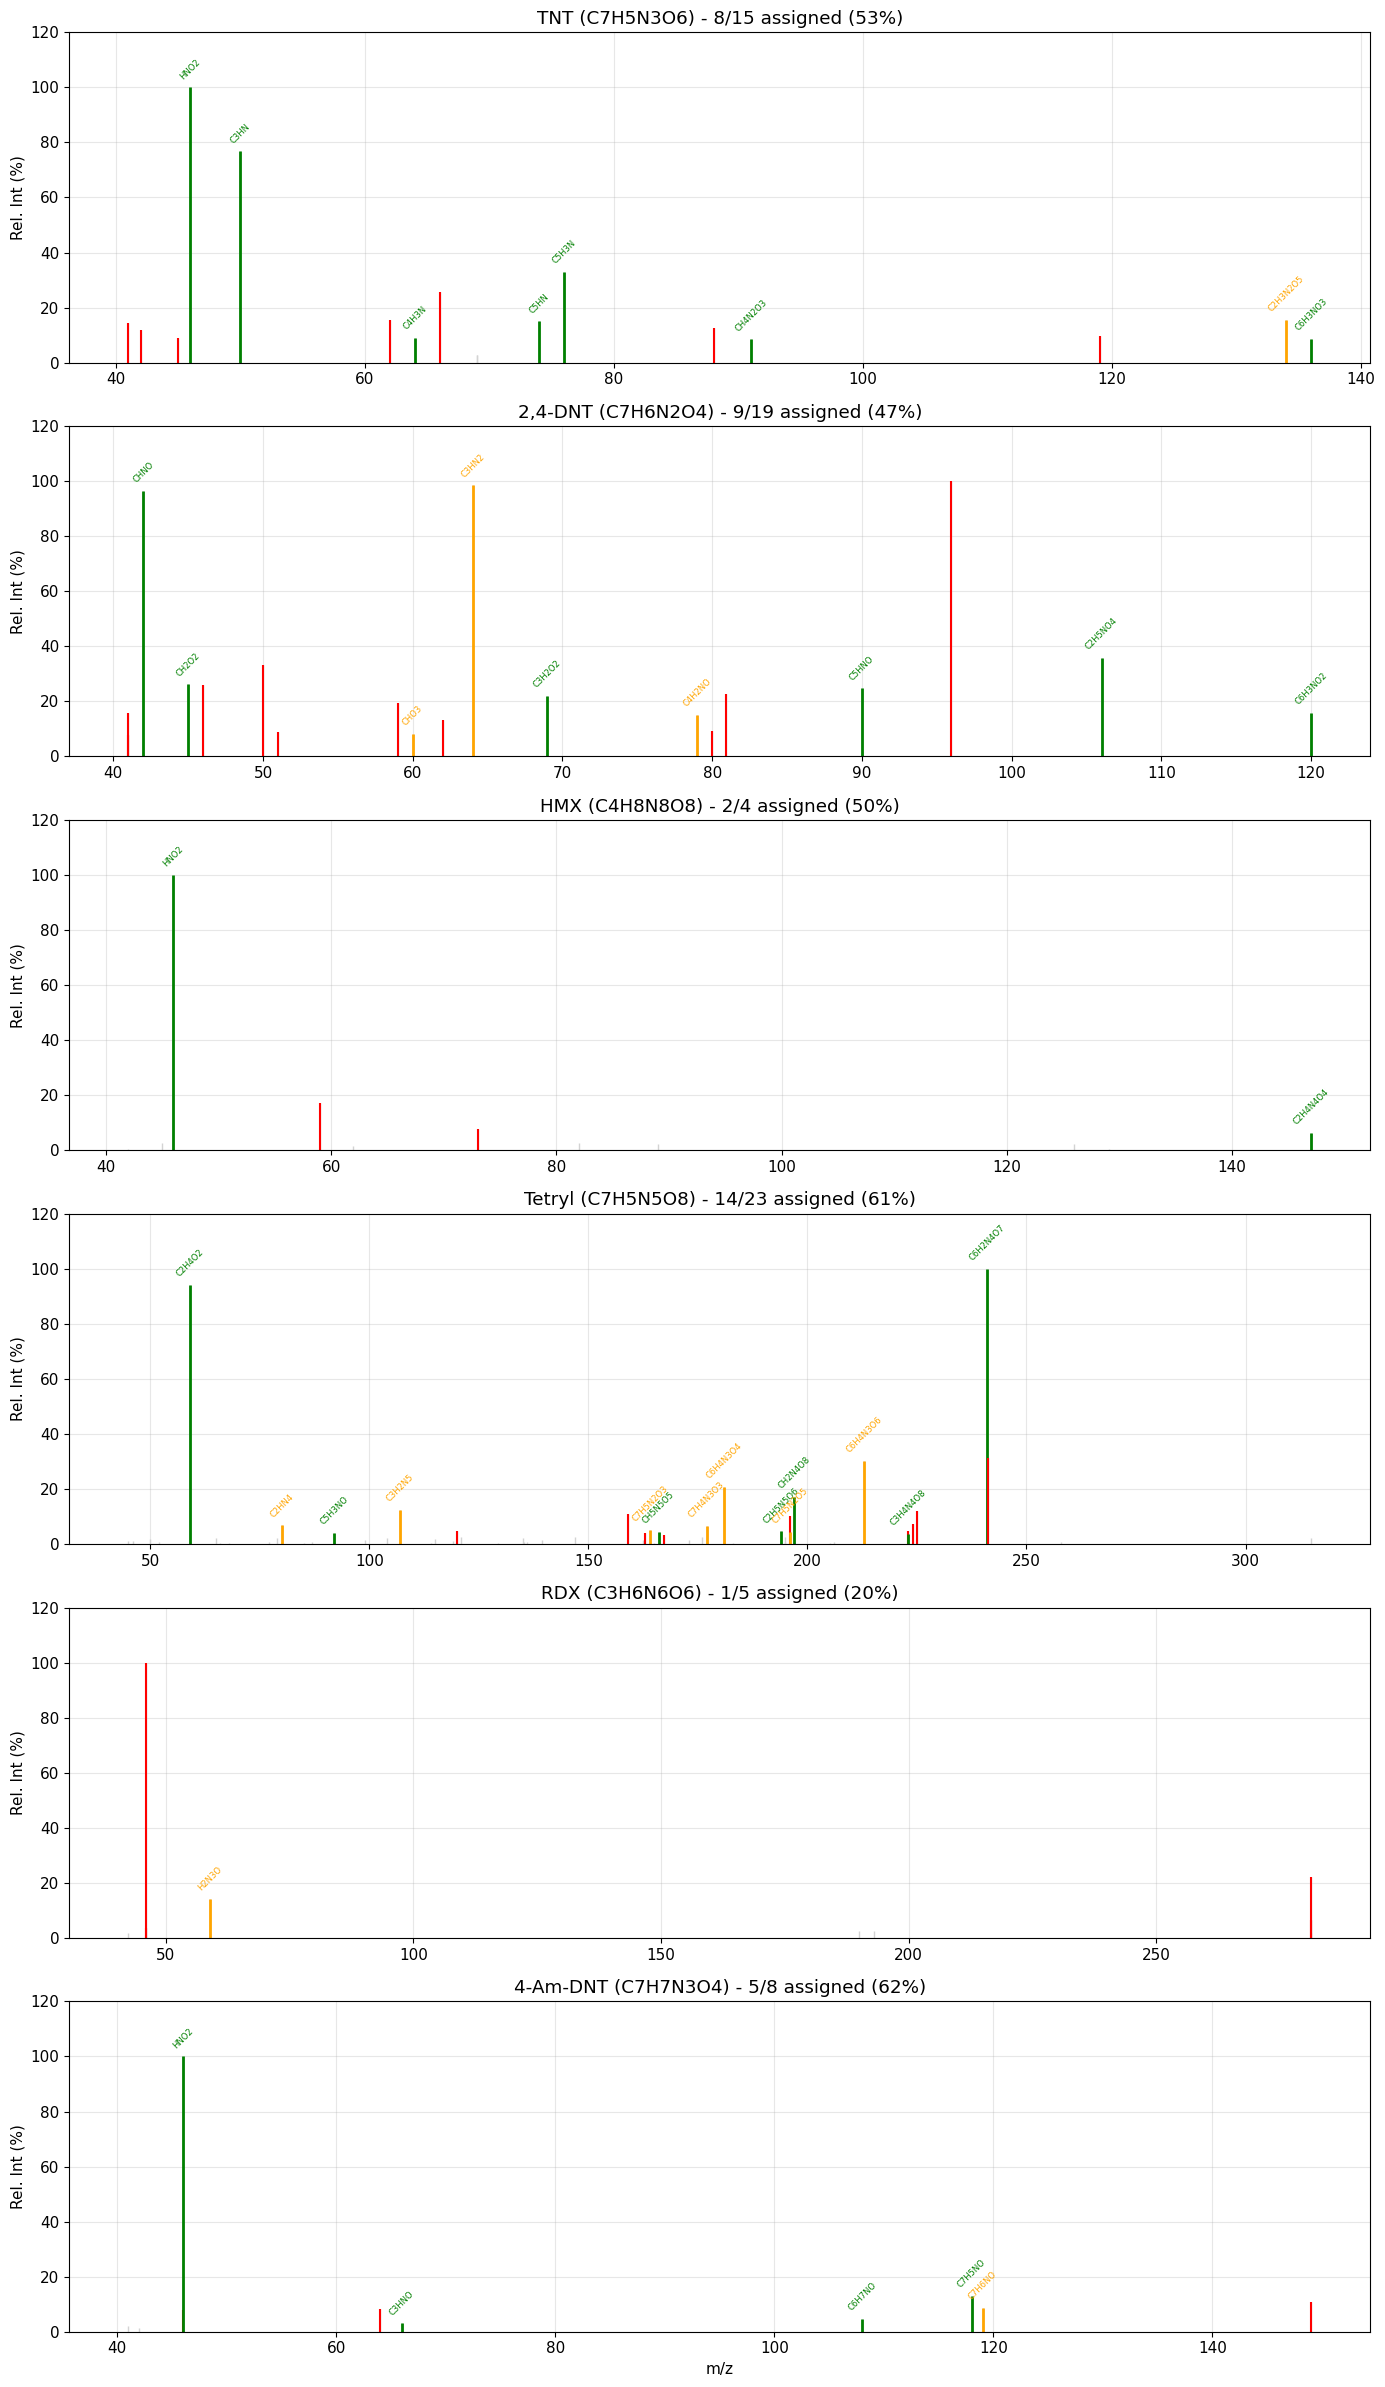

In [2]:
# Annotated MS/MS for all compounds
n_plots = len(all_results)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4 * n_plots))
if n_plots == 1: axes = [axes]

for ax, res in zip(axes, all_results):
    rel = res['frag_int'] / res['frag_int'].max() * 100
    ax.vlines(res['frag_mz'], 0, rel, colors='lightgray', linewidth=1)
    
    for a in res['assignments']:
        if a['assigned_formula']:
            c = 'green' if a['even_electron'] else 'orange'
            ax.vlines(a['frag_mz'], 0, a['rel_int'], colors=c, linewidth=2)
            ax.annotate(f"{a['assigned_formula']}",
                       (a['frag_mz'], a['rel_int']),
                       textcoords='offset points', xytext=(0, 6),
                       fontsize=6, ha='center', color=c, rotation=45)
        else:
            ax.vlines(a['frag_mz'], 0, a['rel_int'], colors='red', linewidth=1.5)
    
    ax.set_title(f"{res['name']} ({res['formula']}) - {res['n_assigned']}/{res['n_total']} assigned ({res['rate']:.0f}%)")
    ax.set_ylabel('Rel. Int (%)')
    ax.set_ylim(0, 120)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('m/z')
plt.tight_layout()
plt.show()

---
## 정리

| 단계 | 입력 | 출력 | 방법 |
|------|------|------|------|
| 화학 필터링 | 후보 목록 | 유효한 fragment | DBE, 전자 상태, 포함 관계 |
| 할당 | 유효 후보 + 실측 피크 | 최적 매칭 | 최소 오차 선택 |
| 물 손실 체인 | fragment 목록 | 연속 손실 패턴 | pairwise delta mass 탐색 |
| 종합 점수 | 전체 할당 결과 | 동정 품질 | 강도 가중 평균 오차 |

### 핵심 포인트
- SMILES/구조 없이 **분자식만으로** fragment 할당 가능
- 부모 포함 조건이 불가능한 fragment를 걸러냄
- 미할당 피크에는 penalty 부여 → 점수에 반영
- 높은 할당률 + 낮은 점수 = 분자식 동정 확실

---

⬅️ **Prev:** [Formula Identification](10%20Formula%20Identification.ipynb) | **Next:** [Reaction Prediction](12%20Reaction%20Prediction.ipynb) ➡️